# Simple Data Aquisitions using Zurich Instruments MFLI

#### To use this notebook, connect the V+ Signal Output to V+ Signal Input

## Connect to Instrument

In [14]:
from zhinst.toolkit import Session
import pandas as pd
import time
import h5py
import numpy as np
import re
import os
import matplotlib.pyplot as plt

session = Session("192.168.60.246")

device = session.connect_device("DEV3901")

## Test Connection

#### If the power LED blinks for a few seconds, the device has successfully connected.

In [15]:
device.system.identify(True)

## Set Input Scaling and Set Ouput Port to 0V

In [16]:
device.sigins[0].scaling(1.40000000) # Scaling to correct offset
device.sigouts[0].on(0)

## Set up DAQ Module for Data Aquisition

In [17]:
daq_module = session.modules.daq

daq_module.triggernode('/dev3901/demods/0/sample.R')
daq_module.type(0)
daq_module.clearhistory(1)
daq_module.bandwidth(0.00000000)
daq_module.historylength(1000000000000000)

# Directory to save files to
daq_module.save.directory(r'C:\Users\BaughLaflamme\Desktop\T16 Thermal ALD SET Room Temperature Test With Lock-In')
daq_module.save.filename("test")
daq_module.save.fileformat(4) # 1 for csv, 4 for hdf5

## Start DAQ and Subscribe to the data that needs to be logged

In [18]:
daq_module.endless(1)
daq_module.subscribe('/dev3901/demods/0/sample.R.avg')
#daq_module.subscribe('/dev3901/demods/0/sample.Theta.avg')
#daq_module.subscribe('/dev3901/demods/0/sample.X.avg')
#daq_module.subscribe('/dev3901/demods/0/sample.Y.avg')
daq_module.execute()

## Turn On Output and Set Amplitude

In [19]:
device.sigouts[0].on(1)
device.sigouts[0].amplitudes[1](0.05000000)
time.sleep(1)

## Turn Off Output

In [20]:
device.sigouts[0].on(0)

## Stop DAQ and Unsubscribe to all the data

In [21]:
daq_module.finish()
daq_module.unsubscribe('*')
time.sleep(1)

## Save the data in the save directory specified above

In [22]:
data = daq_module.save.save(1)
time.sleep(0.5)

## Load Saved Data

#### Note: Works only for HDF5 Datatype

In [23]:
pattern = re.compile(r"test_(\d+)")
max_number = -1
max_file = None

for filename in os.listdir(r'C:\Users\BaughLaflamme\Desktop\T16 Thermal ALD SET Room Temperature Test With Lock-In'):
    match = pattern.search(filename)
    if match:
        number = int(match.group(1))
        if number > max_number:
            max_number = number
            max_file = filename

file_path = r"C:\Users\BaughLaflamme\Desktop\T16 Thermal ALD SET Room Temperature Test With Lock-In" + "\\" + max_file + "\\test_00000.h5"

print(file_path)

dataframes = []

with h5py.File(file_path, 'r') as f:
    for group_name in f.keys():  # e.g. '000', '001', ...
        try:
            timestamp_path = f"{group_name}/dev3901/demods/0/sample.r.avg/timestamp"
            value_path = f"{group_name}/dev3901/demods/0/sample.r.avg/value"

            timestamps = f[timestamp_path][:]
            values = f[value_path][:]

            df = pd.DataFrame({
                "timestamp": timestamps,
                "value": values,
                "group": group_name
            })

            dataframes.append(df)
        except KeyError as e:
            print(f"Skipping {group_name}: {e}")

# Concatenate all into one DataFrame
full_df = pd.concat(dataframes, ignore_index=True)

C:\Users\BaughLaflamme\Desktop\T16 Thermal ALD SET Room Temperature Test With Lock-In\test_005\test_00000.h5


## Plot Saved Data

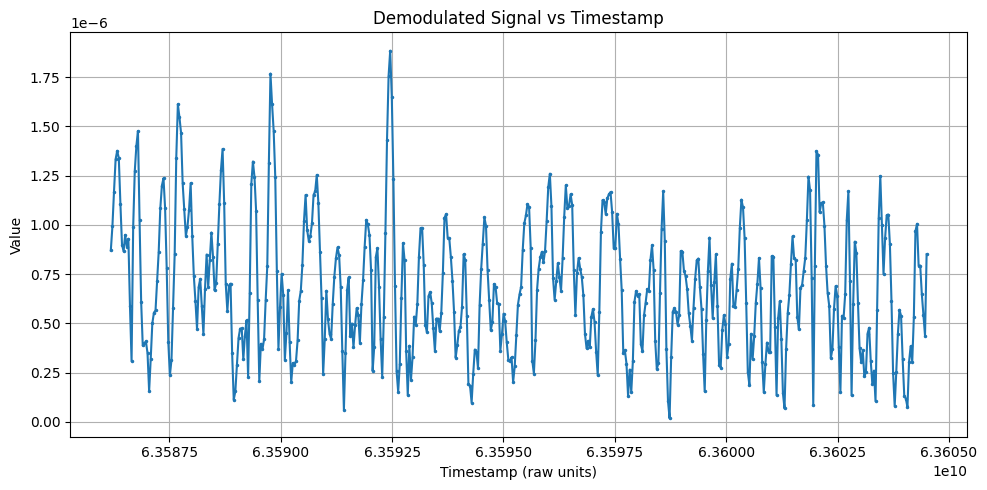

In [24]:
plt.figure(figsize=(10, 5))
plt.plot(full_df['timestamp'], full_df['value'], marker='.', linestyle='-', markersize=3)
plt.xlabel("Timestamp (raw units)")
plt.ylabel("Value")
plt.title("Demodulated Signal vs Timestamp")
plt.grid(True)
plt.tight_layout()
plt.show()